In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
from neuralforecast.auto import NHITS
from neuralforecast.core import NeuralForecast
from neuralforecast.losses.pytorch import MSE
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,root_mean_squared_error
from feature_engine.datetime import DatetimeFeatures
from feature_engine.creation import CyclicalFeatures
from feature_engine.timeseries.forecasting import ExpandingWindowFeatures,LagFeatures
from sktime.transformations.series.fourier import FourierFeatures

from sklearn.preprocessing import MinMaxScaler,StandardScaler
from feature_engine.timeseries.forecasting import WindowFeatures
import holidays
import xgboost
from sklearn.ensemble import RandomForestRegressor


In [2]:
# Check if CUDA is available
print("CUDA available:", torch.cuda.is_available())

# Print the GPU being used
print("Current device:", torch.cuda.current_device())

# Print the name of the GPU
print("GPU in use:", torch.cuda.get_device_name(torch.cuda.current_device()))

CUDA available: True
Current device: 0
GPU in use: NVIDIA RTX 2000 Ada Generation


In [3]:
def CreateWorkHourFeature(input_data):
    """
    Receives as input a DataFrame or Series and outputs a DataFrame with the working hours during the day.
    When the day of the week is larger than 4, it is considered a weekend (1), otherwise, it's a workday (0).
    During workdays and between 8:00 and 17:00, it is considered a working hour.

    Parameters:
    input_data (DataFrame or Series): Input data with a DatetimeIndex.

    Returns:
    DataFrame: DataFrame with the added "WorkingHour_flag" column.
    """
    if isinstance(input_data, pd.Series):
        input_df = pd.DataFrame(input_data)
    elif isinstance(input_data, pd.DataFrame):
        input_df = input_data
    else:
        raise ValueError("Input must be a DataFrame or Series.")

    assert isinstance(input_df.index, pd.DatetimeIndex), "Index must be a datetime index."

    input_df["dayOfWeek"] = input_df.index.dayofweek
    input_df.loc[input_df["dayOfWeek"] > 4, "weekendFlag"] = 1
    input_df.loc[input_df["dayOfWeek"] < 5, "weekendFlag"] = 0
    input_df["hour"] = input_df.index.hour
    input_df["WorkingHour_flag"] = 0
    input_df.loc[((input_df["hour"] > 8) & (input_df["hour"] < 17) & (input_df["weekendFlag"] == 0)), "WorkingHour_flag"] = 1
    input_df.drop(["hour", "dayOfWeek", "weekendFlag"], axis=1, inplace=True)

    return input_df


def ListCreatorFlagger(df, substrings=['flag', 'cos', 'sin','day_of_week', 'day_of_month', 'weekend', 'days_in_month', 'hour', 'minute']):
    """
    A function that separates the columns containing specified substrings from those that don't.
    df is the dataframe in question and the substring is a list.
    """
    flag_columns = [col for col in df.columns if any(substring in col for substring in substrings)]

    if not flag_columns:
        print("No columns with the specified substrings found.")
        return None, None

    non_flag_columns = [col for col in df.columns if col not in flag_columns]

    return non_flag_columns, flag_columns


def HolidayFeatureCreator(input_data):
    """
    Receives as input a DataFrame or Series and creates a column named "Holidays_flag" with 1 if there is a holiday and with 0 if no holidays exist.
    Holidays derived from Germany.
    """
    if isinstance(input_data, pd.Series):
        input_df = pd.DataFrame(input_data)
    elif isinstance(input_data, pd.DataFrame):
        input_df = input_data
    else:
        raise ValueError("Input must be a DataFrame or Series.")

    assert isinstance(input_df.index, pd.DatetimeIndex), "Index must be a datetime index."

    national_holidays_all = holidays.DE(years=[2014,2015,2016,2017,2018,2019,2020, 2021, 2022, 2023, 2024, 2025, 2026]).items()
    national_holidays = [items[0] for items in national_holidays_all]  # this is a list
    
    # Create a new column for holidays flag
    input_df["Holidays_flag"] = 0
    
    # Iterate over the index and set holiday flag to 1 if the date matches any national holiday
    for index_date in input_df.index:
        if index_date.date() in national_holidays:
            input_df.at[index_date, "Holidays_flag"] = 1
    
    return input_df




def TimeRelatedFeatureConstructor(df):
  """
  Works only in a dataframe as input: run the other functions first.
  Extracts time-related features
  """
  TimeFeaturesToExtract=["day_of_week","weekend","hour","minute",] #consider to add more
  dtfs=DatetimeFeatures(variables="index", features_to_extract=TimeFeaturesToExtract, drop_original=False)
  df=dtfs.fit_transform(df)

  CyclicalFeaturesToExtract=["day_of_week","hour","minute",]
  cyclical_dtfs=CyclicalFeatures(variables=CyclicalFeaturesToExtract,drop_original=False)
  df=cyclical_dtfs.fit_transform(df)
  return df


def FourierFeatureConstructor(df,granularity,fourier_terms_list):
    
    number_part = ''.join(filter(str.isdigit, granularity))
    number_int = int(number_part)
    minutes4hour=60/number_int
    
    Fourier_Transformer=FourierFeatures(
        sp_list=[minutes4hour, 24*minutes4hour,24*7*minutes4hour,24*30*minutes4hour],   # hourly, 24 is daily seasonality *12 because for 60 min we have 12 intervals,  and 24*7 is weekly seasonality
        fourier_terms_list=fourier_terms_list,
        freq=granularity, #not necessery
        keep_original_columns=True,

    )

    Fourier_Transformer.fit(df)
    df=Fourier_Transformer.transform(df)
    return df

def WindowFeaturesConstructor(df, granularity, ListWithNoFlags):
    """
    This is a function that makes a list of 4 window features starting from double the granularity and following by doubling the previous value
    """
    number_part = ''.join(filter(str.isdigit, granularity))
    number_int = int(number_part)
    double_granularity = 2 * number_int
    time_intervals = [double_granularity]
    
    # Calculate subsequent values
    for i in range(3):
        time_intervals.append(time_intervals[-1] * 2)
    
    windowlist = [interval // number_int for interval in time_intervals]  # Corrected division
    functionsList = ["mean", "std"]
    WindownFeatureTransformer = WindowFeatures(variables=ListWithNoFlags,
                                               functions=functionsList,
                                               window=windowlist,
                                               freq=granularity,
                                               drop_original=False)

    df = WindownFeatureTransformer.fit_transform(df)
    return df

def ExpandingWindowFeatureConstructor(df,ListWithNoFlags):
  functionsList=["mean","std"]
  frequency = pd.infer_freq(df.index) #infer the frequency from the dataframe
  ExpandingWindownFeatureTransformer=ExpandingWindowFeatures(variables=ListWithNoFlags,
                                                           functions=functionsList,
                                                           freq=frequency, #I put the freq to shift it down! but now it is performed automatically!
                                                           drop_original=False)
  df=ExpandingWindownFeatureTransformer.fit_transform(df)
  return df

def WeightedLinearFeatureMaker(df,ListWithNoFlags,granularity):
  """
  This is a function that takes the original DF and modifies the continious value columns
  Inputs: Dataframe, List of columns that are continous values, daily window to slide, weights of the values
  """
  number_part = ''.join(filter(str.isdigit, granularity))
  Minutedensity=int(number_part)
  Window=int((60/Minutedensity)*24) #288 means a daily window
  weights=np.arange(1,Window+1)

  # if i had hourly data then i would have had np.arange(1,24*7) for a weekly window

  def weighted_mean (x,weights):
    return (weights*x).sum()/weights.sum()

  def weighted_std(x,weights):
    mean_w= weighted_mean(x, weights)
    var_w= (weights* (x-mean_w)**2).sum()/weights.sum()
    return np.sqrt(var_w)

  # LETS make the weighted mean column
  for i in ListWithNoFlags:
    result=(
        df[i]
        .rolling(window=Window) #here we pick a window size. Needs to be the same as the len(weights)
        .apply(weighted_mean, args=(weights,))
        .shift(1)#shift by 1 to avoid data leakage
        .to_frame()#convert series to df
        )

    result.columns=[str(i)+"_weighted_"+str(Window)+"_mean"]
    df=df.join(result)

  for i in ListWithNoFlags:
    result=(
        df[i]
        .rolling(window=Window) #here we pick a window size. Needs to be the same as the len(weights)
        .apply(weighted_std, args=(weights,))
        .shift(1)#shift by 1 to avoid data leakage
        .to_frame()#convert series to df
        )

    result.columns=[str(i)+"_weighted_"+str(Window)+"_std"]
    df=df.join(result)
  return df

def ExpWeightMeanMaker(df,ListWithNoFlags,granularity):
  """
  This is a function that makes exp weighted average with a sliding window approach
  """
  number_part = ''.join(filter(str.isdigit, granularity))
  Minutedensity=int(number_part)
  Window=int((60/Minutedensity)*24) #288 means a daily window
  
  def exp_weights(alpha,window_size):
    """
    a function to calculate the weights for every single component of our sliding windown
    """
    weights=np.ones(window_size) #initializing weights
    for ix in range(window_size):
      weights[ix]=(1-alpha)**(window_size-1-ix)
    return weights

  def exp_weighted_mean(x):
    """
    a functions that calculates the exp weigted mean
    """

    weights=exp_weights(alpha=0.05, window_size=len(x)) # HERE WE SET THE ALPHA
    return (weights*x).sum()/weights.sum()
  
  for i in ListWithNoFlags:
    result=(
        df[i]
        .rolling(window=int(Window))
        .agg([exp_weighted_mean])
        .shift(1)
    )


    result.columns=[str(i)+"_Exp_weighted_"+str(Window)+"_SL.win"]
    df=df.join(result)
  return df

def WeightedExponentialExpandingWindow(df,ListWithNoFlags,alpha):
  """
  This is a funtion that takes as input the df,a list of continuous values and the alpha.
  Outputs: all continuous features on the df that are "mean" and "std"
  """

  for i in ListWithNoFlags:
    df[[str(i)+"_ewm_mean_expanding.win",str(i)+"ewm_std_expanding.win"]]= (
                                              df[i].ewm(alpha=alpha).
                                              agg(["mean","std"])
                                              .shift(1)
                                            )
  return df

def FeatureLagger(df,ListOfFeatures,granularity,PredictionHorizon):

    time_intervals = []
    number_part = ''.join(filter(str.isdigit, granularity))
    Minutedensity=int(number_part)
    end_in_day=int((PredictionHorizon)/(Minutedensity))
    for i in range(1, 1+end_in_day):  # 24 hours * 60 minutes / 15 minutes = 96 intervals
        time_intervals.append(f"{i * 15}min")

    lag_transformer= LagFeatures(variables=ListOfFeatures,
                                freq=time_intervals,
                                drop_original=False) #make a lagger transformer drop all original features

    df=lag_transformer.fit_transform(df) # transform the features to DF joined
    return df

In [4]:
def ErrorCalculator(name, y_true, y_pred):
    errors = {"Pipelines": name,
              "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
              "MAE": mean_absolute_error(y_true, y_pred),
              "MSE": mean_squared_error(y_true, y_pred),
              
              "PMAE": peak_MAE(y_true, y_pred),
              "PMSE": peak_MSE(y_true, y_pred),
              "PRMSE": peak_RMSE(y_true, y_pred),
              
              "VMAE": valley_MAE(y_true, y_pred),
              "VMSE": valley_MSE(y_true, y_pred),
              "VRMSE": valley_RMSE(y_true, y_pred),
              
              "xMAE": extreme_MAE(y_true, y_pred),
              "xMSE": extreme_MSE(y_true, y_pred),
              "xRMSE": extreme_RMSE(y_true, y_pred),
             }
    return errors

def peak_MAE(y_true, y_pred, threshold=2000):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    filtered_indices = y_true > threshold
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    mse = mean_absolute_error(filtered_real_values, filtered_predictions)
    return mse

def peak_MSE(y_true, y_pred, threshold=2000):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    filtered_indices = y_true > threshold
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    mse = mean_squared_error(filtered_real_values, filtered_predictions)
    return mse

def peak_RMSE(y_true, y_pred, threshold=2000):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    filtered_indices = y_true > threshold
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    rmse = np.sqrt(mean_squared_error(filtered_real_values, filtered_predictions))
    return rmse

def valley_MAE(y_true, y_pred, lower_threshold=-2000):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    filtered_indices = y_true < lower_threshold
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    mse = mean_absolute_error(filtered_real_values, filtered_predictions)
    return mse

def valley_MSE(y_true, y_pred, lower_threshold=-2000):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    filtered_indices = y_true < lower_threshold
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    mse = mean_squared_error(filtered_real_values, filtered_predictions)
    return mse

def valley_RMSE(y_true, y_pred, lower_threshold=-2000):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    filtered_indices = y_true < lower_threshold
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    rmse = np.sqrt(mean_squared_error(filtered_real_values, filtered_predictions))
    return rmse
def extreme_MAE(y_true, y_pred, lower_threshold=-2000, upper_threshold=2000):
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Filter the indices where the true values are either below the lower threshold or above the upper threshold
    filtered_indices = (y_true < lower_threshold) | (y_true > upper_threshold)
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Absolute Error (MAE) for the filtered data
    mae = mean_absolute_error(filtered_real_values, filtered_predictions)
    return mae

def extreme_MSE(y_true, y_pred, lower_threshold=-2000, upper_threshold=2000):
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Filter the indices where the true values are either below the lower threshold or above the upper threshold
    filtered_indices = (y_true < lower_threshold) | (y_true > upper_threshold)
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Mean Squared Error (MSE) for the filtered data
    mse = mean_squared_error(filtered_real_values, filtered_predictions)
    return mse

def extreme_RMSE(y_true, y_pred, lower_threshold=-2000, upper_threshold=2000):
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Filter the indices where the true values are either below the lower threshold or above the upper threshold
    filtered_indices = (y_true < lower_threshold) | (y_true > upper_threshold)
    
    # Filter both predictions and true values based on these indices
    filtered_predictions = y_pred[filtered_indices]
    filtered_real_values = y_true[filtered_indices]
    
    # Calculate the Root Mean Squared Error (RMSE) for the filtered data
    rmse = np.sqrt(mean_squared_error(filtered_real_values, filtered_predictions))
    return rmse


In [5]:
df = pd.read_csv(r"C:\Users\CR58XM\Desktop\NZEB_net_load_forecasting\inputs\Clean_NISThomeAllfeatures.csv",index_col=0, parse_dates=[0])

#all dataframes should have these columns ['unique_id', 'ds', 'y']
# in this case the y is the price and the rest are covariates

# setting up the scenario parameters

In [6]:
#Calculate NetLoad!
OriginalFeatures=["NetLoad"]
scenario="1"
season="winter" #for winter it works!
OutputPath = r"C:\Users\CR58XM\Desktop\NZEB_net_load_forecasting\outputs"

granularity="15min"
prediction_horizon="1440min"

number_part_hor = ''.join(filter(str.isdigit, prediction_horizon))
PredictionHorizon=int(number_part_hor)
number_part = ''.join(filter(str.isdigit, granularity))
Minutedensity=int(number_part)
fourier_terms_list=[2,2,2,2]
prediction_horizon_steps=PredictionHorizon//Minutedensity # this is 96

In [7]:
if season=="summer":
    #df = df[df.index.month.isin([5, 6, 7, 8])]
    df = df[((df.index.month == 7) & (df.index.day <= 15)) |  # First half of July
            ((df.index.month == 3) & (df.index.day > 15)) |   # Last half of March
            (df.index.month.isin([4, 5, 6]))]                # April, May, June

    #df = df.sort_index()  # Ensure proper chronological order

elif season=="winter":
    df=df[df.index.month.isin([9, 10, 11, 12])]

#keep the features that are needed for each scenario
if scenario=="0":
    df["NetLoad"]=df["Total_load"]-df["SolarPower"]
    df=df[["NetLoad"]]

"""if scenario=="1":
    #forecasting Net load only with features from the past
    df["NetLoad"]=df["Total_load"]-df["SolarPower"]
    df=df[["NetLoad","T_out","Irradiance"]]
    OriginalFeatures=["NetLoad","T_out","Irradiance"]    """


if scenario=="1":
    #forecasting Net load only with features from the past
    df["NetLoad"]=df["Total_load"]-df["SolarPower"]
    df=df[["NetLoad","T_out","Irradiance","Wind_speed"]]
    OriginalFeatures=["NetLoad","T_out","Irradiance","Wind_speed"]


if scenario=="2":
    #forecasting Net load with features from the past and future
    df["NetLoad"]=df["Total_load"]-df["SolarPower"]
    df=df[["NetLoad","T_out","Irradiance","Wind_speed"]]
    
if scenario=="3":
    #forecasting household load and SolarPower with features from the past. Then combine them to get the NetLoad
    df=df[["Total_load","T_out","Irradiance","Wind_speed","SolarPower"]]
    
if scenario=="4":
    #forecasting household load with features from the past and future. Then combine them to get the NetLoad 
    df=df[["Total_load","T_out","Irradiance","Wind_speed","SolarPower"]]

In [8]:
df

,NetLoad,T_out,Irradiance,Wind_speed
2015-09-01 00:00:00,321.361626,22.870824,0.000964,2.380000
2015-09-01 00:15:00,992.385435,22.748477,0.000942,2.626667
2015-09-01 00:30:00,374.223879,22.541770,0.000931,2.140000
2015-09-01 00:45:00,861.487071,22.424297,0.000943,2.020000
2015-09-01 01:00:00,415.110060,22.272275,0.000947,1.873333
...,...,...,...,...
2015-12-31 22:45:00,806.483673,5.039256,0.000962,2.493333
2015-12-31 23:00:00,694.377304,4.607881,0.000888,2.813333
2015-12-31 23:15:00,1141.953873,4.868095,0.001034,2.380000
2015-12-31 23:30:00,1189.757622,4.809239,0.000953,1.840000


In [9]:
#Positive and negative load
df["NetLoad_flag"]=0 #zero for negativeload
df.loc[((df["NetLoad"]>=0)),"NetLoad_flag"]=1 #1 if it is positibe load

# Daily peaks
df["Small_peak_flag"] = 0  # Initialize with 0
df.loc[df["NetLoad"] >= 2000, "Small_peak_flag"] = 1  # Set to 1 where NetLoad is above 2000


# Weekly peaks
df["Medium_peak_flag"] = 0  # Initialize with 0
df.loc[df["NetLoad"] >= 4000, "Medium_peak_flag"] = 1  # Set to 1 where NetLoad is above 4000

# Monthly peaks
df["Large_peak_flag"] = 0  # Initialize with 0
df.loc[df["NetLoad"] >= 5500, "Large_peak_flag"] = 1  # Set to 1 where NetLoad is above 5500


# Daily valleys
df["Small_valley_flag"] = 0
df.loc[df["NetLoad"] <= -2000, "Small_valley_flag"] = 1 # Set daily_valley to 1 where NetLoad is below -2000

# Weekly valleys
df["Medium_valley_flag"] = 0
df.loc[df["NetLoad"] <= -4000, "Medium_valley_flag"] = 1 # Set daily_valley to 1 where NetLoad is below -2000

# Monthly valleys
df["Large_valley_flag"] = 0
df.loc[df["NetLoad"] <= -5500, "Large_valley_flag"] = 1 # Set daily_valley to 1 where NetLoad is below -2000

In [10]:
df=HolidayFeatureCreator(df)
df=CreateWorkHourFeature(df)
df=TimeRelatedFeatureConstructor(df)
df=FourierFeatureConstructor(df,granularity,fourier_terms_list)
ListWithNoFlags,ListWithFlags=ListCreatorFlagger(df)
df=WindowFeaturesConstructor(df,granularity,ListWithNoFlags)
df=ExpandingWindowFeatureConstructor(df,ListWithNoFlags)
df=WeightedLinearFeatureMaker(df,ListWithNoFlags,granularity)
df=ExpWeightMeanMaker(df,ListWithNoFlags,granularity)
df=WeightedExponentialExpandingWindow(df,ListWithNoFlags,0.5)
df=FeatureLagger(df,OriginalFeatures,granularity,PredictionHorizon)

In [11]:
#make the target
df["NetLoad_+lag"+str(PredictionHorizon)]=df["NetLoad"].shift(int(-PredictionHorizon/Minutedensity))

target="NetLoad_+lag"+str(PredictionHorizon)
df.dropna(inplace=True)

In [12]:
# Step 1: Determine the number of rows in the DataFrame
total_size = len(df)

# Step 2: Define the number of rows for validation and test sets
validation_test_size = 96*7*2

# Step 3: Split the data
DF_training = df.iloc[:total_size - 2 * validation_test_size]
DF_validation = df.iloc[total_size - 2 * validation_test_size:total_size - validation_test_size]
DF_test = df.iloc[total_size - validation_test_size:]

# Step 4: Verify the sizes of each set
print("Training set size:", len(DF_training))
print("Validation set size:", len(DF_validation))
print("Test set size:", len(DF_test))



Training set size: 8832
Validation set size: 1344
Test set size: 1344


# XGboost for validation

In [13]:

# Define the RandomForestRegressor
"""
regressor = xgboost.XGBRegressor(
    n_estimators=500,  # Number of boosting rounds (equivalent to number of trees)
    random_state=42,   # Ensure reproducibility
    tree_method='gpu_hist',  # Use GPU-accelerated tree construction
    predictor='gpu_predictor',  # Use GPU for prediction
)
"""
regressor = xgboost.XGBRegressor(
    random_state=42,
    tree_method="hist",
    device="cuda",
)

X_train=DF_training.drop([target],axis=1) # df, all features except target in a dataframe for the first period
X_test=DF_validation.drop([target],axis=1) #df , all feature except target (same as before but for the next available period period)
y_train=DF_training[target] #one column df, of the target for the first period
y_test=DF_validation[target] #one column df of the target for the next period

regressor.fit(X_train , y_train)

predicted_val = regressor.predict(X_test)

[10:23:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.



# Xgboost for test

In [14]:
DF_training_and_DF_validation=pd.concat([DF_training,DF_validation])

X_train=DF_training_and_DF_validation.drop([target],axis=1) # df, all features except target in a dataframe for the first period
X_test=DF_test.drop([target],axis=1) #df , all feature except target (same as before but for the next available period period)
y_train=DF_training_and_DF_validation[target] #one column df, of the target for the first period
y_test=DF_test[target] #one column df of the target for the next period



# get the feature importance 

# Feature selection

In [16]:
def plot_errors (ErrorSeries):
  """
  This is a function that plots the features that are not
  """
  import matplotlib as mpl
  import matplotlib.pyplot as plt
  import matplotlib.path as mpath
  import numpy as np

  import matplotlib.pyplot as plt
  import numpy as np

  x = np.arange(len(ErrorSeries.index))
  y = ErrorSeries.values
  labels = ErrorSeries.index

  plt.figure(1,figsize=(13,5))
  plt.style.use("seaborn-v0_8-whitegrid")
  plt.plot(x, y)

  plt.xticks(x, labels, rotation =40)
  plt.ylabel('MSE [W^2]', wrap=True)
  plt.xlabel('Features', wrap=True)


  plt.margins(0.05)

  plt.subplots_adjust(bottom = 0.05)
  plt.show()
  

def FeatureSelectionWithSHAP1_fixed_test(regressor, DF_features, DF_target, ordered_features_list, test_size=672, tolerance=100):
    """
    This function receives a regressor model, the features that the model was trained with,
    and the target that it had to forecast. Starting from the most important feature, 
    we find the error of the TimeSeries Cross-Validation with a fixed test size.
    By adding features, we find the new error of the forecast.

    Parameters:
    - regressor: The regression model to use for training and prediction.
    - DF_features: DataFrame containing the features.
    - DF_target: Series containing the target variable.
    - ordered_features_list: List of features ordered by importance (e.g., from SHAP analysis).
    - test_size: Number of steps to use in the test set (default is 672).
    - tolerance: Number of features to add before stopping if no improvement in error (default is 20).

    Returns:
    - ErrorSeries: A pandas Series with the errors for each step of feature addition.
    """

    feature_list = []  # Empty list of features
    error_list = []  # Empty list to store errors for each set of features
    total_samples = len(DF_features)  # Total number of samples in the dataset
    n_splits = 5  # Number of splits (fixed)
    no_improvement_count = 0  # Count features added without improvement
    min_error = float('inf')  # Start with a large error to track the minimum error

    for i in ordered_features_list:
        # Start the loop with the best feature and append the next ones
        feature_list.append(i)

        X = DF_features[feature_list].to_numpy()
        y = DF_target.to_numpy()

        #print(f"Performing feature selection with features: {feature_list}")

        # Custom logic to create splits with a fixed test size of 672
        splits = []
        start_train_size = total_samples - (n_splits * test_size)  # Calculate where to start training

        for split in range(n_splits):
            train_end = start_train_size + split * test_size
            test_start = train_end
            test_end = test_start + test_size

            if test_end <= total_samples:  # Ensure the test set is within the bounds
                splits.append((list(range(0, train_end)), list(range(test_start, test_end))))

        TimeSeriesCVerror = []  # MSE errors for each fold

        # Time series cross-validation with fixed test size
        for train_index, test_index in splits:
            #print(f"TRAIN: {train_index}, TEST: {test_index}")
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            
            # Train the regressor and predict
            regressor.fit(X_train, y_train)
            predicted_val = regressor.predict(X_test)
            
            # Calculate the error for this fold
            Error = mean_squared_error(y_test, predicted_val)
            TimeSeriesCVerror.append(Error)
            #print(f"This is the error for one TS iteration: {Error}")

        # Calculate the average error across all splits
        TS_CV_error = sum(TimeSeriesCVerror) / len(TimeSeriesCVerror)
        #print(f"Cumulative error of the last steps: {TS_CV_error}")
        error_list.append(TS_CV_error)  # Store the error for this set of features

        # Check if the error improved
        if TS_CV_error < min_error:
            min_error = TS_CV_error  # Update the minimum error
            no_improvement_count = 0  # Reset the no-improvement count
        else:
            no_improvement_count += 1  # Increment if there's no improvement

        # Break the loop if no improvement is observed after 20 features
        if no_improvement_count >= tolerance:
            print(f"No improvement after {tolerance} features. Stopping early.")
            break

    # Create a pandas Series to store the error associated with each feature
    ErrorSeries = pd.Series(error_list, index=feature_list)

    # Plot the errors using a custom plot function
    plot_errors(ErrorSeries)

    return ErrorSeries

## Checkpoint

In [39]:
#save the first series which is the error and the features
FSname1="new_selected_features_and_errors.csv"
Joined_DF_FilePath=os.path.join(OutputPath,FSname1)
FirstSeries.to_csv(Joined_DF_FilePath)

In [40]:
#save the features
FSname1 = "new_selected_features_step1.csv"
FilePath = os.path.join(OutputPath, FSname1)
features_after_FS1_df = pd.DataFrame(features_after_FS1, columns=["Features"])

# Save the DataFrame to the constructed file path
features_after_FS1_df.to_csv(FilePath, index=False)


In [17]:
# Read the CSV file into a DataFrame
FSname1 = "selected_features_step1.csv"
FilePath = os.path.join(OutputPath, FSname1)
features_after_FS1_df = pd.read_csv(FilePath)
features_after_FS1 = features_after_FS1_df["Features"].tolist()



In [18]:
features_after_FS1

['cos_2880.0_2',
 'Wind_speed_expanding_std',
 'NetLoad',
 'NetLoadewm_std_expanding.win',
 'NetLoad_lag_1440min',
 'Wind_speed_lag_855min',
 'NetLoad_window_8_std',
 'Irradiance_lag_1260min',
 'T_out_window_16_std',
 'NetLoad_lag_1425min',
 'NetLoad_Exp_weighted_96_SL.win',
 'hour_cos',
 'Wind_speed_window_8_mean',
 'Wind_speed_lag_570min',
 'Wind_speed_lag_1395min',
 'Irradiance_lag_1320min',
 'Irradiance_lag_1170min',
 'T_out_weighted_96_mean',
 'Wind_speed_lag_495min',
 'Wind_speed_lag_1275min',
 'NetLoad_lag_975min',
 'sin_2880.0_2',
 'Irradiance_lag_1410min',
 'NetLoad_lag_990min',
 'T_out_lag_1140min',
 'NetLoad_lag_1080min',
 'Wind_speed_lag_1185min',
 'Irradiance_lag_585min',
 'T_out_lag_300min',
 'Wind_speed',
 'NetLoad_lag_1305min',
 'Wind_speed_window_8_std',
 'Wind_speed_lag_330min',
 'Wind_speed_lag_435min',
 'Wind_speed_lag_900min',
 'T_out_lag_315min',
 'Irradiance_lag_1305min',
 'Irradiance_window_2_std',
 'Wind_speed_ewm_mean_expanding.win',
 'NetLoad_window_16_std',


# HPO feature selection

In [40]:
best_params={'n_estimators': 258,
 'max_depth': 8,
 'learning_rate': 0.17550464989560502,
 'reg_alpha': 0.8163532576754263,
 'reg_lambda': 0.40388591126957757}

Top 25 features coverage: 77.06%


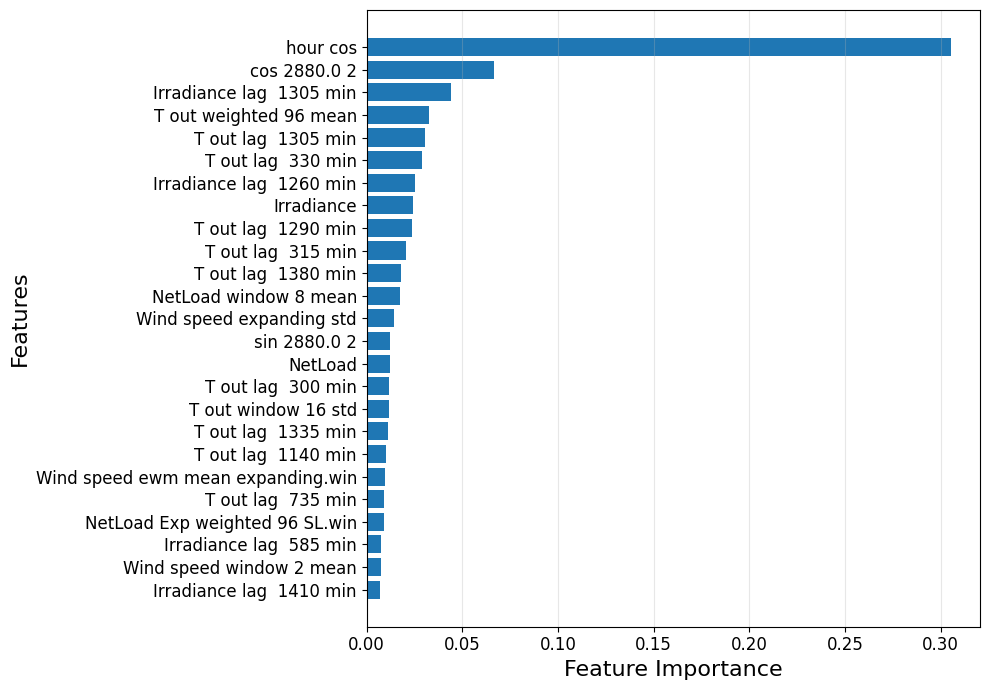

In [ ]:
import matplotlib.pyplot as plt

DF_training_and_DF_validation=pd.concat([DF_training,DF_validation])

X_train=DF_training_and_DF_validation[features_after_FS1] # df, all features except target in a dataframe for the first period
X_test=DF_test[features_after_FS1] #df , all feature except target (same as before but for the next available period period)
y_train=DF_training_and_DF_validation[target] #one column df, of the target for the first period
y_test=DF_test[target] #one column df of the target for the next period

regressor = xgboost.XGBRegressor(
    random_state=42,
    tree_method="hist",
    device="cuda",
    **best_params
)


regressor.fit(X_train , y_train)

predicted_val = regressor.predict(X_test)


# ===== STYLE =====
TITLE_FS = 16
LABEL_FS = 16
TICK_FS = 12
LEGEND_FS = 11
LINEWIDTH = 1.5
MARKER_SIZE = 5

importances = regressor.feature_importances_

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})



# Sort and keep top 10
top = (
    importance_df
    .sort_values(by="importance", ascending=False)
    .head(25)
    .sort_values(by="importance", ascending=True)  # for nice horizontal plot
)


# =========================
# ===== CLEAN FEATURE NAMES (optional but recommended) =====
# =========================
top["feature_clean"] = (
    top["feature"]
    .str.replace("_", " ")
    .str.replace("lag", "lag ")
    .str.replace("min", " min")
)


# Total importance (robust, even if not exactly 1.0)
total_importance = importance_df["importance"].sum()

# Coverage of top N features
coverage = top["importance"].sum() / total_importance

print(f"Top {len(top)} features coverage: {coverage*100:.2f}%")

# =========================
# ===== PLOT =====
# =========================
plt.figure(figsize=(10, 7))  # slightly taller for readability

plt.barh(
    top["feature_clean"],   # use cleaned names
    top["importance"]
)

plt.xlabel("Feature Importance", fontsize=LABEL_FS)
plt.ylabel("Features", fontsize=LABEL_FS)

plt.xticks(fontsize=TICK_FS)

# Option 1: clean (recommended for paper)
plt.yticks(fontsize=TICK_FS)

#Option 2: slight diagonal
#plt.yticks(fontsize=TICK_FS, rotation=20, ha='right')

plt.grid(True, axis='x', alpha=0.3)

plt.tight_layout()

# =========================
# ===== SAVE =====
# =========================
save_path = r"C:\Users\CR58XM\Desktop\top10_features.pdf"
plt.savefig(save_path, bbox_inches="tight")

plt.show()

In [30]:
import pandas as pd
import numpy as np

# Feature importance
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": regressor.feature_importances_
})

# Sort descending
importance_df = importance_df.sort_values(by="importance", ascending=False)

# Normalize (important for interpretability)
importance_df["importance_norm"] = (
    importance_df["importance"] / importance_df["importance"].sum()
)

# Cumulative importance
importance_df["cumulative"] = importance_df["importance_norm"].cumsum()

# Keep features up to 95%
importance_95 = importance_df[importance_df["cumulative"] <= 0.85]

# Include the first feature that crosses 95%
if importance_df["cumulative"].iloc[len(importance_95)] > 0.85:
    importance_95 = pd.concat([
        importance_95,
        importance_df.iloc[[len(importance_95)]]
    ])

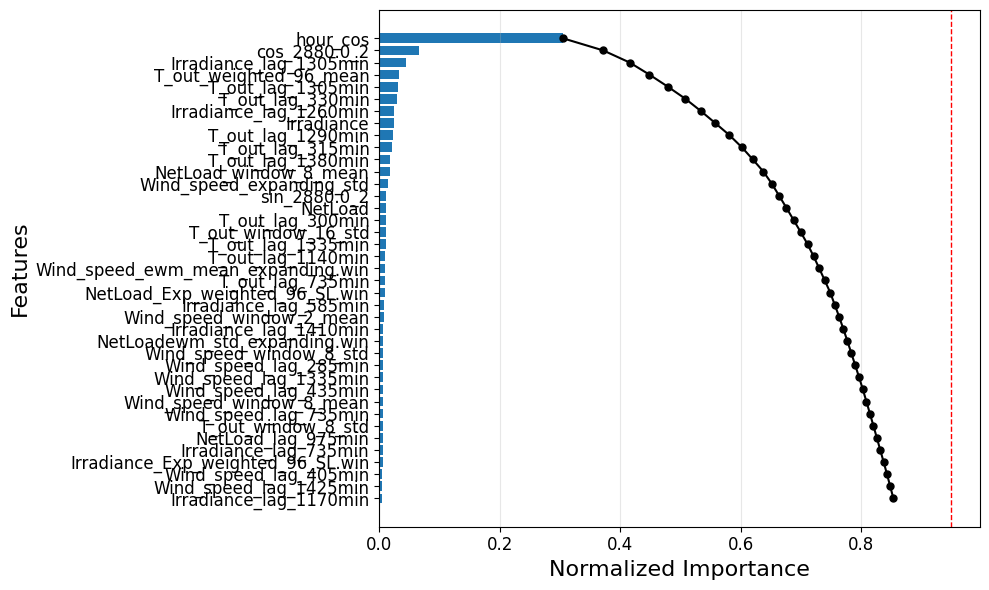

In [31]:
import matplotlib.pyplot as plt

# ===== STYLE =====
TITLE_FS = 16
LABEL_FS = 16
TICK_FS = 12
LEGEND_FS = 11
LINEWIDTH = 1.5
MARKER_SIZE = 5

# Reverse for barh
plot_df = importance_95.sort_values(by="importance_norm", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["feature"],
    plot_df["importance_norm"]
)

# Optional: cumulative line (VERY useful)
plt.plot(
    plot_df["cumulative"],
    plot_df["feature"],
    color="black",
    linewidth=LINEWIDTH,
    marker='o',
    markersize=MARKER_SIZE
)

# 95% threshold line
plt.axvline(0.95, color='red', linestyle='--', linewidth=1)

plt.xlabel("Normalized Importance", fontsize=LABEL_FS)
plt.ylabel("Features", fontsize=LABEL_FS)

plt.xticks(fontsize=TICK_FS)
plt.yticks(fontsize=TICK_FS)

plt.grid(True, axis='x', alpha=0.3)

plt.tight_layout()

plt.savefig(r"C:\Users\CR58XM\Desktop\feature_importance_95.pdf", bbox_inches="tight")
plt.show()

[10:48:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

Top 25 SHAP features coverage: 74.70%
                         feature   importance  cumulative_coverage
0                   cos_2880.0_2  1094.932495             0.308493
11                      hour_cos   202.903259             0.365660
1       Wind_speed_expanding_std   201.223541             0.422354
2                        NetLoad   190.855179             0.476127
36        Irradiance_lag_1305min   107.683128             0.506466
17        T_out_weighted_96_mean    91.815155             0.532335
7         Irradiance_lag_1260min    89.476738             0.557545
21                  sin_2880.0_2    73.287849             0.578193
22        Irradiance_lag_1410min    63.138020             0.595982
72              T_out_lag_330min    53.101734             0.610943
4            NetLoad_lag_1440

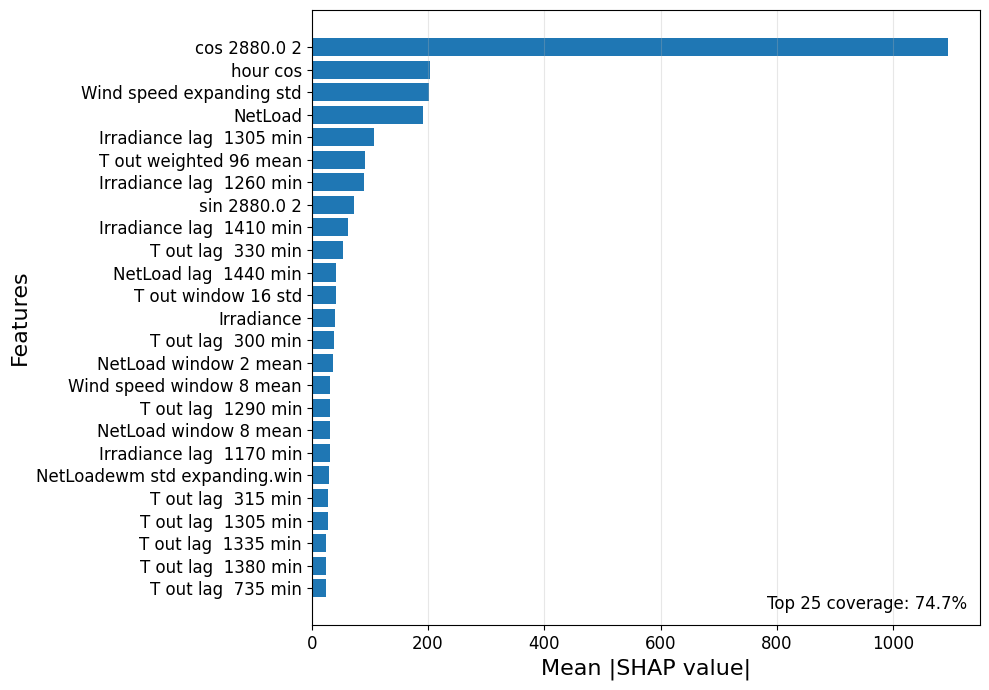

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xgboost
import shap

# =========================
# ===== DATA PREP =====
# =========================
DF_training_and_DF_validation = pd.concat([DF_training, DF_validation])

X_train = DF_training_and_DF_validation[features_after_FS1]
X_test  = DF_test[features_after_FS1]
y_train = DF_training_and_DF_validation[target]
y_test  = DF_test[target]

# =========================
# ===== MODEL =====
# =========================
regressor = xgboost.XGBRegressor(
    random_state=42,
    tree_method="hist",
    device="cuda",
    **best_params
)

regressor.fit(X_train, y_train)
predicted_val = regressor.predict(X_test)

# =========================
# ===== STYLE =====
# =========================
TITLE_FS = 16
LABEL_FS = 16
TICK_FS = 12
LEGEND_FS = 11
LINEWIDTH = 1.5
MARKER_SIZE = 5

# =========================
# ===== SHAP VALUES =====
# =========================
explainer = shap.TreeExplainer(regressor)
shap_values = explainer.shap_values(X_train)

# If target is univariate regression, shap_values should be 2D: [n_samples, n_features]
# Mean absolute SHAP importance
shap_importance = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": shap_importance
})

# =========================
# ===== TOP N FEATURES =====
# =========================
TOP_N = 25

top = (
    importance_df
    .sort_values(by="importance", ascending=False)
    .head(TOP_N)
    .sort_values(by="importance", ascending=True)
    .copy()
)

# Clean labels
top["feature_clean"] = (
    top["feature"]
    .str.replace("_", " ", regex=False)
    .str.replace("lag", "lag ", regex=False)
    .str.replace("min", " min", regex=False)
)

# Coverage of top N
total_importance = importance_df["importance"].sum()
coverage = top["importance"].sum() / total_importance

print(f"Top {len(top)} SHAP features coverage: {coverage*100:.2f}%")

# Optional: print the selected features and their cumulative share
top_desc = (
    importance_df
    .sort_values(by="importance", ascending=False)
    .head(TOP_N)
    .copy()
)
top_desc["cumulative_coverage"] = top_desc["importance"].cumsum() / total_importance

print(top_desc[["feature", "importance", "cumulative_coverage"]])

# =========================
# ===== PLOT =====
# =========================
plt.figure(figsize=(10, 7))

plt.barh(
    top["feature_clean"],
    top["importance"]
)

plt.xlabel("Mean |SHAP value|", fontsize=LABEL_FS)
plt.ylabel("Features", fontsize=LABEL_FS)

plt.xticks(fontsize=TICK_FS)
plt.yticks(fontsize=TICK_FS)

plt.grid(True, axis='x', alpha=0.3)

# Show coverage on figure
plt.text(
    0.98, 0.02,
    f"Top {len(top)} coverage: {coverage*100:.1f}%",
    transform=plt.gca().transAxes,
    ha='right',
    va='bottom',
    fontsize=TICK_FS
)

plt.tight_layout()

save_path = r"C:\Users\CR58XM\Desktop\top25_shap_features.pdf"
plt.savefig(save_path, bbox_inches="tight")
plt.show()

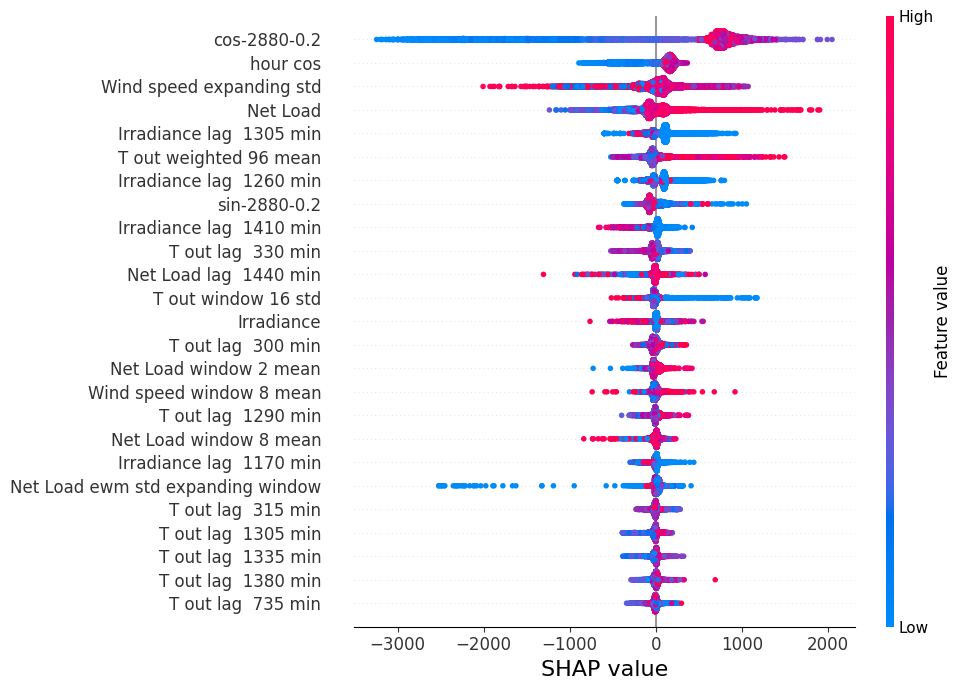

In [59]:
import shap
import matplotlib.pyplot as plt

# ===== STYLE =====
TITLE_FS = 16
LABEL_FS = 16
TICK_FS = 12
LEGEND_FS = 11
LINEWIDTH = 1.5
MARKER_SIZE = 5

# =========================
# SHAP VALUES
# =========================
explainer = shap.TreeExplainer(regressor)
shap_values = explainer.shap_values(X_train)

# =========================
# CLEAN FEATURE NAMES
# =========================
X_train_clean = X_train.copy()
X_train_clean.columns = (
    X_train_clean.columns
    .str.replace("_", " ", regex=False)
    .str.replace("NetLoad", "Net Load", regex=False)
    .str.replace("ewm", " ewm", regex=False)
    .str.replace("lag", "lag ", regex=False)
    .str.replace("min", " min", regex=False)
    .str.replace("expanding.win", "expanding window", regex=False)
    .str.replace("cos 2880.0 2", "cos-2880-0.2", regex=False)
    .str.replace("sin 2880.0 2", "sin-2880-0.2", regex=False)

)

# =========================
# PLOT
# =========================
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_train_clean,
    max_display=25,
    show=False
)

ax = plt.gca()

# Tick sizes
ax.tick_params(axis="x", labelsize=TICK_FS)
ax.tick_params(axis="y", labelsize=TICK_FS)

# Keep the normal centered xlabel
ax.set_xlabel("SHAP value", fontsize=LABEL_FS)

# No manual label repositioning
# ax.xaxis.set_label_coords(...)

# Keep original-looking layout
plt.gcf().set_size_inches(10, 7)
plt.tight_layout()

plt.savefig(r"C:\Users\CR58XM\Desktop\shap_summary_top25.pdf", bbox_inches="tight")
plt.show()

# end